In [1]:
%pip install -q wandb
# !wandb login
# c44fdddfecae9d75682399ff1644ac20985484ee


[notice] A new release of pip is available: 23.3.1 -> 25.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
!git clone https://github.com/clausmichele/CBSD68-dataset

Cloning into 'CBSD68-dataset'...
remote: Enumerating objects: 564, done.
remote: Total 564 (delta 0), reused 0 (delta 0), pack-reused 564 (from 1)
Receiving objects: 100% (564/564), 181.30 MiB | 39.33 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [ ]:
from dataset import load_datasets, show
from model import UNet

# from train import Trainer
from ..Denoising_DnCNN.train import Trainer
# use same trainer and metrics as for DnCNN

In [ ]:
# RTC:CBSD68-dataset/CBSD68/noisy35
train_d, test_d = load_datasets("CBSD68-dataset/CBSD68/noisy35", "CBSD68-dataset/CBSD68/original_png")

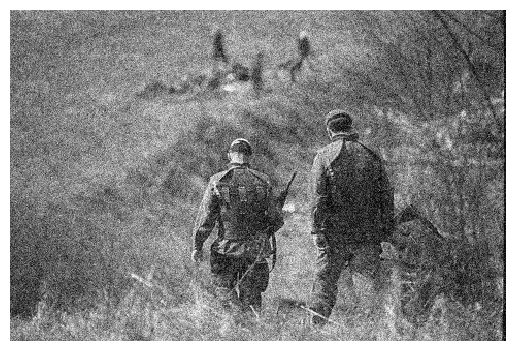

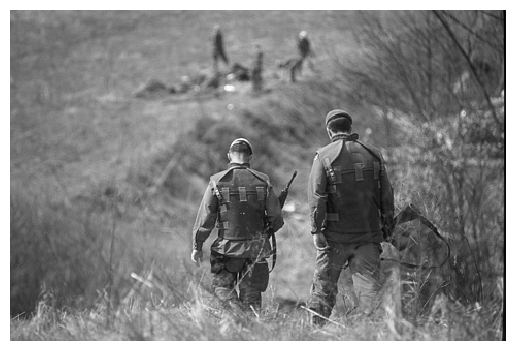

(None, None)

In [5]:
show(train_d[17][0]), show(train_d[17][1])

In [ ]:
import gc

import torch

gc.collect()
torch.cuda.empty_cache()

In [ ]:
def hyperparameter_tuning(train_loader, test_loader, save_dir="models", wandb_project="unet-tuning", wandb_entity=None):
    sweep_config = {
        "method": "random",
        "metric": {"name": "val_loss", "goal": "minimize"},
        "parameters": {
            "batch_size": {"values": [4, 8, 16]},
            "learning_rate": {"distribution": "log_uniform_values", "min": 1e-4, "max": 1e-2},
            "epochs": {"values": [50, 100, 150]},
            "patience": {"values": [5, 10, 15]}
        }
    }
    sweep_id = wandb.sweep(sweep_config, project=wandb_project, entity=wandb_entity)

    def train_sweep(config=None):
        with wandb.init(config=config):
            config = wandb.config  # Access the current sweep config

            print(f"\n {config}")

            model = UNet(1, 1)  # Replace with your actual model
            trainer = Trainer(
                model, train_loader, test_loader, save_dir,
                batch_size=config.batch_size,
                lr=config.learning_rate,
                n_epoch=config.epochs,
                patience=config.patience,
                wandb_project=wandb_project,
                wandb_entity=wandb_entity
            )
            trainer.train()

    wandb.agent(sweep_id, train_sweep, count=10)

In [ ]:
import wandb

hyperparameter_tuning(train_d, test_d)

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Create sweep with ID: hrw1yydt
Sweep URL: https://wandb.ai/firefly334/unet-tuning/sweeps/hrw1yydt


wandb: Agent Starting Run: ok1f5yye with config:
wandb: 	batch_size: 4
wandb: 	epochs: 100
wandb: 	learning_rate: 0.002677281059803843
wandb: 	patience: 10
wandb: Currently logged in as: omkar334 (firefly334) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin



 {'batch_size': 4, 'epochs': 100, 'learning_rate': 0.002677281059803843, 'patience': 10}
2025-04-01 18:34:43: Epoch 1: Train Loss = 0.1061, Val Loss = 1805.8623, Time = 3.66s
2025-04-01 18:34:47: Epoch 2: Train Loss = 0.0174, Val Loss = 0.0163, Time = 2.94s
2025-04-01 18:34:51: Epoch 3: Train Loss = 0.0153, Val Loss = 0.0110, Time = 3.13s
2025-04-01 18:34:55: Epoch 4: Train Loss = 0.0159, Val Loss = 0.0137, Time = 3.20s
2025-04-01 18:34:59: Epoch 5: Train Loss = 0.0164, Val Loss = 0.0149, Time = 2.99s
2025-04-01 18:35:03: Epoch 6: Train Loss = 0.0150, Val Loss = 0.0109, Time = 3.08s
2025-04-01 18:35:07: Epoch 7: Train Loss = 0.0135, Val Loss = 0.0113, Time = 3.25s
2025-04-01 18:35:11: Epoch 8: Train Loss = 0.0143, Val Loss = 0.0098, Time = 3.05s
2025-04-01 18:35:15: Epoch 9: Train Loss = 0.0144, Val Loss = 0.0109, Time = 3.17s
2025-04-01 18:35:19: Epoch 10: Train Loss = 0.0156, Val Loss = 0.0131, Time = 2.98s
2025-04-01 18:35:23: Epoch 11: Train Loss = 0.0161, Val Loss = 0.0154, Time 

epoch,▁▁▁▁▂▂▂▃▃▃▃▃▃▃▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇█
time,▃▆▄▄▆▃▅▆▅▄▄▇▄▅▅▄█▇▆▇▃▁▂▁▁▁▁▁▃▁▁▂▃▂▁▂▂▂▁▂
train_loss,█▆▇▆▅▄▆▅▇▅▄▃▃▅▃▂▃▂▂▂▃▂▂▂▁▃▁▂▃▂▁▂▁▂▃▂▂▂▁▁
val_loss,▂▂▁▂▂▁▁▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▅▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,100
time,2.85182
train_loss,0.00905
val_loss,0.0078


wandb: Agent Starting Run: ukjc6env with config:
wandb: 	batch_size: 8
wandb: 	epochs: 50
wandb: 	learning_rate: 0.0004975401452880508
wandb: 	patience: 5



 {'batch_size': 8, 'epochs': 50, 'learning_rate': 0.0004975401452880508, 'patience': 5}
2025-04-01 18:41:13: Epoch 1: Train Loss = 0.2090, Val Loss = 0.9808, Time = 2.83s
2025-04-01 18:41:17: Epoch 2: Train Loss = 0.0212, Val Loss = 7.0874, Time = 2.69s
2025-04-01 18:41:20: Epoch 3: Train Loss = 0.0132, Val Loss = 0.1407, Time = 2.76s
2025-04-01 18:41:24: Epoch 4: Train Loss = 0.0133, Val Loss = 0.0370, Time = 2.89s
2025-04-01 18:41:29: Epoch 5: Train Loss = 0.0129, Val Loss = 0.0211, Time = 2.90s
2025-04-01 18:41:33: Epoch 6: Train Loss = 0.0127, Val Loss = 0.0210, Time = 2.81s
2025-04-01 18:41:37: Epoch 7: Train Loss = 0.0110, Val Loss = 0.0101, Time = 2.74s
2025-04-01 18:41:41: Epoch 8: Train Loss = 0.0143, Val Loss = 0.0098, Time = 2.82s
2025-04-01 18:41:45: Epoch 9: Train Loss = 0.0113, Val Loss = 0.0187, Time = 2.94s
2025-04-01 18:41:49: Epoch 10: Train Loss = 0.0115, Val Loss = 0.0185, Time = 2.78s
2025-04-01 18:41:54: Epoch 11: Train Loss = 0.0117, Val Loss = 0.0091, Time = 3.